# Bottle Damage Classifier — ResNet50V2 + TFLite Export (Kaggle)
**Pipeline:** Data prep → Augmentation → Transfer learning → Evaluation → TFLite INT8 export

**Classes:** `Damaged` | `Not Damaged`

**Backbone:** ResNet50V2 pretrained on ImageNet



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [58]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'
import zipfile

ZIP_PATH = '/content/drive/MyDrive/edge/dataset.zip'
EXTRACT_PATH = '/content/dataset_extracted'

if os.path.exists(ZIP_PATH):
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)
    print(f'Successfully extracted dataset to {EXTRACT_PATH}')
    print('Folders found:', os.listdir(EXTRACT_PATH))
else:
    print(f'Error: Zip file not found at {ZIP_PATH}')

Successfully extracted dataset to /content/dataset_extracted
Folders found: ['dataset', '__MACOSX', '.ipynb_checkpoints']


In [9]:
DATASET_DIR = '/content/dataset_extracted/dataset' # Using extracted folder
OUTPUT_DIR = '/content/working'
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS_FROZEN = 15
EPOCHS_FINETUNE = 20
SEED = 42
CLASS_NAMES = ['damaged', 'non_damaged']

os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'Dataset directory: {DATASET_DIR}')

for cls in CLASS_NAMES:
    p = os.path.join(DATASET_DIR, cls)
    if os.path.exists(p):
        n = len([f for f in os.listdir(p) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        print(f'  ✓ {cls}: {n} images')
    else:
        print(f'  ✗ {cls}: NOT FOUND — check folder names in zip')

Dataset directory: /content/dataset_extracted/dataset
  ✓ damaged: 526 images
  ✓ non_damaged: 173 images


## Step 0 — Verify GPU and import libraries

In [2]:
!pip install -q tensorflow matplotlib seaborn scikit-learn pillow

In [3]:
import os, zipfile, shutil, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.preprocessing import image_dataset_from_directory
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

print('TensorFlow version :', tf.__version__)
print('GPU available       :', tf.config.list_physical_devices('GPU'))
# print('Kaggle input dir    :', os.listdir('/kaggle/input/'))

TensorFlow version : 2.20.0
GPU available       : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Kaggle input dir    : []


## Step 1 — Config

**Only thing you need to change:** set `DATASET_NAME` to match the name of your Kaggle dataset.

In [12]:
DATASET_DIR    = '/content/dataset_extracted/dataset'   # Updated to Drive path
OUTPUT_DIR     = '/content/working'
IMG_SIZE       = (224, 224)
BATCH_SIZE     = 16
EPOCHS_FROZEN  = 15
EPOCHS_FINETUNE= 20
SEED           = 42
CLASS_NAMES    = ['damaged', 'non_damaged']

os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'Dataset directory: {DATASET_DIR}')

for cls in CLASS_NAMES:
    p = os.path.join(DATASET_DIR, cls)
    if os.path.exists(p):
        n = len([f for f in os.listdir(p) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        print(f'  ✓ {cls}: {n} images')
    else:
        print(f'  ✗ {cls}: NOT FOUND — check folder names')

Dataset directory: /content/dataset_extracted/dataset
  ✓ damaged: 526 images
  ✓ non_damaged: 173 images


## Step 3 — Split into train / val / test

In [29]:
import shutil

SPLIT_DIR  = '/content/working/split'
TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15

# Clean up previous split to ensure a fresh start
if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)

random.seed(SEED)

for split in ['train', 'val', 'test']:
    for cls in CLASS_NAMES:
        os.makedirs(os.path.join(SPLIT_DIR, split, cls), exist_ok=True)

for cls in CLASS_NAMES:
    # Sort first to ensure shuffle is deterministic across different runs
    files = sorted([f for f in os.listdir(os.path.join(DATASET_DIR, cls))
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

    random.shuffle(files)

    n     = len(files)
    n_tr  = int(n * TRAIN_FRAC)
    n_val = int(n * VAL_FRAC)

    splits = {
        'train': files[:n_tr],
        'val'  : files[n_tr:n_tr + n_val],
        'test' : files[n_tr + n_val:]
    }

    for split, flist in splits.items():
        for f in flist:
            shutil.copy(
                os.path.join(DATASET_DIR, cls, f),
                os.path.join(SPLIT_DIR, split, cls, f)
            )
        print(f"  {cls}/{split}: {len(flist)} images")

# Data Leakage Check
train_files = set(os.listdir(os.path.join(SPLIT_DIR, 'train', 'damaged')))
test_files = set(os.listdir(os.path.join(SPLIT_DIR, 'test', 'damaged')))
overlap = train_files.intersection(test_files)
print(f"\nOverlap check (damaged): {len(overlap)} files overlapping.")

print("Split complete with fresh directories.")

  damaged/train: 368 images
  damaged/val: 78 images
  damaged/test: 80 images
  non_damaged/train: 121 images
  non_damaged/val: 25 images
  non_damaged/test: 27 images

Overlap check (damaged): 0 files overlapping.
Split complete with fresh directories.


## Step 4 — Build tf.data pipelines with augmentation

In [30]:
train_ds = image_dataset_from_directory(
    os.path.join(SPLIT_DIR, 'train'),
    image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    shuffle=True, seed=SEED, label_mode='categorical'
)
val_ds = image_dataset_from_directory(
    os.path.join(SPLIT_DIR, 'val'),
    image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    shuffle=False, label_mode='categorical'
)
test_ds = image_dataset_from_directory(
    os.path.join(SPLIT_DIR, 'test'),
    image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    shuffle=False, label_mode='categorical'
)

print('Class names (TF order):', train_ds.class_names)
CLASS_NAMES = train_ds.class_names  # update to exact order TF assigned

Found 489 files belonging to 2 classes.
Found 103 files belonging to 2 classes.
Found 107 files belonging to 2 classes.
Class names (TF order): ['damaged', 'non_damaged']


In [31]:
augment = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.10),          # ±36°
    layers.RandomZoom(0.10),
    layers.RandomBrightness(0.20),
    layers.RandomContrast(0.15),
    layers.GaussianNoise(0.05),           # simulate sensor noise
], name='augmentation')

# ResNet50V2 preprocessing: scales [0,255] → [-1,1]
preprocess = tf.keras.applications.resnet_v2.preprocess_input

AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    train_ds
    .map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=AUTOTUNE)
    .map(lambda x, y: (preprocess(x), y),             num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)
val_ds = (
    val_ds
    .map(lambda x, y: (preprocess(x), y), num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)
test_ds = (
    test_ds
    .map(lambda x, y: (preprocess(x), y), num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

print('Pipelines ready.')


Pipelines ready.


## Step 5 — Visualize augmented samples

Found 489 files belonging to 2 classes.


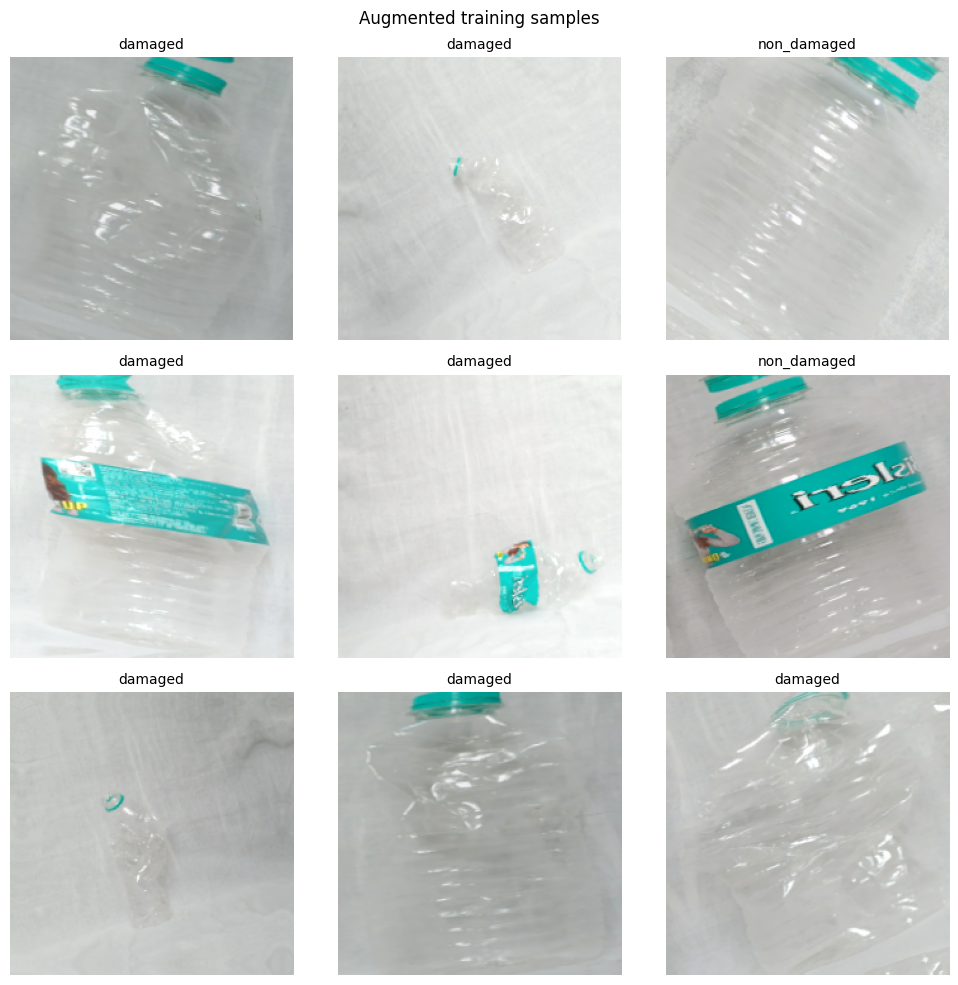

In [32]:
raw_train = image_dataset_from_directory(
    os.path.join(SPLIT_DIR, 'train'),
    image_size=IMG_SIZE, batch_size=9,
    shuffle=True, seed=SEED, label_mode='categorical'
)

plt.figure(figsize=(10, 10))
for images, labels in raw_train.take(1):
    aug_images = augment(images, training=True)
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(aug_images[i].numpy().astype('uint8'))
        cls = CLASS_NAMES[np.argmax(labels[i])]
        plt.title(cls, fontsize=10)
        plt.axis('off')
plt.suptitle('Augmented training samples', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'augmented_samples.png'), dpi=150)
plt.show()


In [33]:
# Gather all training labels
all_labels = []
raw_for_weights = image_dataset_from_directory(
    os.path.join(SPLIT_DIR, 'train'),
    image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    shuffle=False, label_mode='int'
)
for _, labels in raw_for_weights:
    all_labels.extend(labels.numpy().tolist())

all_labels = np.array(all_labels)
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(all_labels),
    y=all_labels
)
CLASS_WEIGHTS = {i: w for i, w in enumerate(class_weights_arr)}
print('Class weights:', CLASS_WEIGHTS)
for i, name in enumerate(CLASS_NAMES):
    print(f'  {name}: {CLASS_WEIGHTS[i]:.4f}')

Found 489 files belonging to 2 classes.
Class weights: {0: np.float64(0.6644021739130435), 1: np.float64(2.020661157024793)}
  damaged: 0.6644
  non_damaged: 2.0207


## Step 6 — Build model

**Phase 1:** ResNet50V2 base frozen — only the classification head trains.

**Phase 2:** Top 30 layers of base unfrozen for fine-tuning.

In [36]:
NUM_CLASSES = len(CLASS_NAMES)
L2          = 1e-4   # L2 regularisation strength for Dense layers

# Load ResNet50V2 without top, pretrained on ImageNet
base_model = ResNet50V2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # frozen in phase 1

print(f'ResNet50V2 total layers: {len(base_model.layers)}')

# Classification head with L2 regularisation on Dense layers
inputs  = tf.keras.Input(shape=IMG_SIZE + (3,))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(256, activation='relu',
                        kernel_regularizer=regularizers.l2(L2))(x)
x       = layers.Dropout(0.57)(x)
x       = layers.Dense(128, activation='relu',
                        kernel_regularizer=regularizers.l2(L2))(x)
x       = layers.Dropout(0.30)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs, outputs, name='bottle_classifier_resnet50v2')
model.summary(line_length=80)


ResNet50V2 total layers: 190


Model: "bottle_classifier_resnet50v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)        │ (None, 224, 224, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ resnet50v2 (Functional)           │ (None, 7, 7, 2048)       │    23,564,800 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ global_average_pooling2d_2        │ (None, 2048)             │             0 │
│ (GlobalAveragePooling2D)          │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_2             │ (None, 2048)             │         8,192 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_6 (Dense)                   │ (None, 256)              │       524,544 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_4 (Dropout)               │ (None, 256)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_7 (Dense)                   │ (None, 128)              │        32,896 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_5 (Dropout)               │ (None, 128)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_8 (Dense)                   │ (None, 2)                │           258 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 24,130,690 (92.05 MB)

 Trainable params: 561,794 (2.14 MB)

 Non-trainable params: 23,568,896 (89.91 MB)

## Step 7 — Phase 1 training (frozen base)

In [37]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
    ]
)

cbs_phase1 = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=5,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=3, min_lr=1e-6, verbose=1),
    callbacks.ModelCheckpoint(
        os.path.join(OUTPUT_DIR, 'best_phase1.keras'),
        monitor='val_accuracy', save_best_only=True, verbose=1
    )
]

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FROZEN,
    class_weight=CLASS_WEIGHTS,
    callbacks=cbs_phase1
)
print(f'\nBest val accuracy (phase 1): {max(history1.history["val_accuracy"]):.4f}')


Epoch 1/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.7319 - loss: 0.8966 - precision: 0.7319 - recall: 0.7319
Epoch 1: val_accuracy improved from None to 0.98058, saving model to /content/working/best_phase1.keras

Epoch 1: finished saving model to /content/working/best_phase1.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 34s 637ms/step - accuracy: 0.8221 - loss: 0.7011 - precision: 0.8221 - recall: 0.8221 - val_accuracy: 0.9806 - val_loss: 0.3514 - val_precision: 0.9806 - val_recall: 0.9806 - learning_rate: 0.0010
Epoch 2/15
30/31 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.8855 - loss: 0.5717 - precision: 0.8855 - recall: 0.8855
Epoch 2: val_accuracy improved from 0.98058 to 1.00000, saving model to /content/working/best_phase1.keras

Epoch 2: finished saving model to /content/working/best_phase1.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 337ms/step - accuracy: 0.9080 - loss: 0.5202 - precision: 0.9080 - recall: 0.9080 - val_accuracy: 1.0000 - val_loss: 0.3083 - val_precision: 1.0000 

## Step 8 — Phase 2: Fine-tune top layers of base

In [38]:
# Unfreeze the top 30 layers of ResNet50V2
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f'Trainable layers in base: {trainable_count} / {len(base_model.layers)}')

# Lower LR — crucial to avoid destroying pretrained weights
model.compile(
    optimizer=tf.keras.optimizers.Adam(5e-6),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
    ]
)

cbs_phase2 = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=7,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=3, min_lr=1e-8, verbose=1),
    callbacks.ModelCheckpoint(
        os.path.join(OUTPUT_DIR, 'best_phase2.keras'),
        monitor='val_accuracy', save_best_only=True, verbose=1
    )
]

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINETUNE,
    class_weight=CLASS_WEIGHTS,
    callbacks=cbs_phase2
)
print(f'\nBest val accuracy (phase 2): {max(history2.history["val_accuracy"]):.4f}')


Trainable layers in base: 30 / 190
Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.9183 - loss: 0.4967 - precision: 0.9183 - recall: 0.9183
Epoch 1: val_accuracy improved from None to 1.00000, saving model to /content/working/best_phase2.keras

Epoch 1: finished saving model to /content/working/best_phase2.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 46s 794ms/step - accuracy: 0.9264 - loss: 0.4859 - precision: 0.9264 - recall: 0.9264 - val_accuracy: 1.0000 - val_loss: 0.2999 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 5.0000e-06
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.9273 - loss: 0.4943 - precision: 0.9273 - recall: 0.9273
Epoch 2: val_accuracy did not improve from 1.00000
31/31 ━━━━━━━━━━━━━━━━━━━━ 9s 272ms/step - accuracy: 0.9100 - loss: 0.5145 - precision: 0.9100 - recall: 0.9100 - val_accuracy: 1.0000 - val_loss: 0.3060 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 5.0000e-06
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 0

In [39]:
MODEL_SAVE_PATH = '/content/working/bottle_classifier_resnet50v2_fp32.keras'

model.save(MODEL_SAVE_PATH)

print(f"Saved FP32 Keras model → {MODEL_SAVE_PATH}")

Saved FP32 Keras model → /content/working/bottle_classifier_resnet50v2_fp32.keras


## Step 9 — Plot training curves

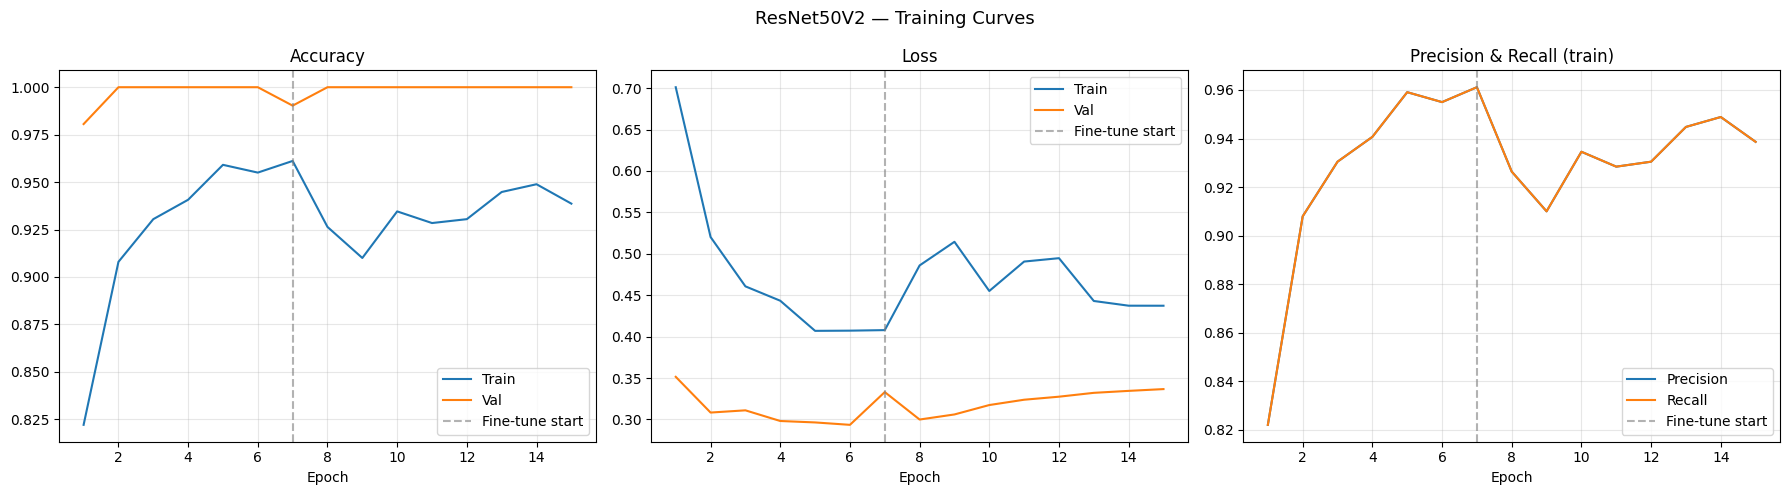

Saved → training_curves.png


In [40]:
def plot_history(h1, h2):
    acc   = h1.history['accuracy']     + h2.history['accuracy']
    vacc  = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss  = h1.history['loss']         + h2.history['loss']
    vloss = h1.history['val_loss']     + h2.history['val_loss']
    prec  = h1.history['precision']    + h2.history['precision']
    rec   = h1.history['recall']       + h2.history['recall']
    ep    = range(1, len(acc) + 1)
    sep   = len(h1.history['accuracy'])

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, train, val, title in [
        (axes[0], acc,  vacc,  'Accuracy'),
        (axes[1], loss, vloss, 'Loss'),
    ]:
        ax.plot(ep, train, label='Train')
        ax.plot(ep, val,   label='Val')
        ax.axvline(sep, linestyle='--', color='gray', alpha=0.6, label='Fine-tune start')
        ax.set_title(title); ax.set_xlabel('Epoch')
        ax.legend(); ax.grid(alpha=0.3)

    axes[2].plot(ep, prec, label='Precision')
    axes[2].plot(ep, rec,  label='Recall')
    axes[2].axvline(sep, linestyle='--', color='gray', alpha=0.6, label='Fine-tune start')
    axes[2].set_title('Precision & Recall (train)')
    axes[2].set_xlabel('Epoch')
    axes[2].legend(); axes[2].grid(alpha=0.3)

    plt.suptitle('ResNet50V2 — Training Curves', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150)
    plt.show()
    print('Saved → training_curves.png')

plot_history(history1, history2)


## Step 10 — Evaluate on test set

In [41]:
y_true, y_pred = [], []

for images, labels in test_ds:
    preds  = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print('\n── Classification Report ──')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


── Classification Report ──
              precision    recall  f1-score   support

     damaged       1.00      1.00      1.00        80
 non_damaged       1.00      1.00      1.00        27

    accuracy                           1.00       107
   macro avg       1.00      1.00      1.00       107
weighted avg       1.00      1.00      1.00       107



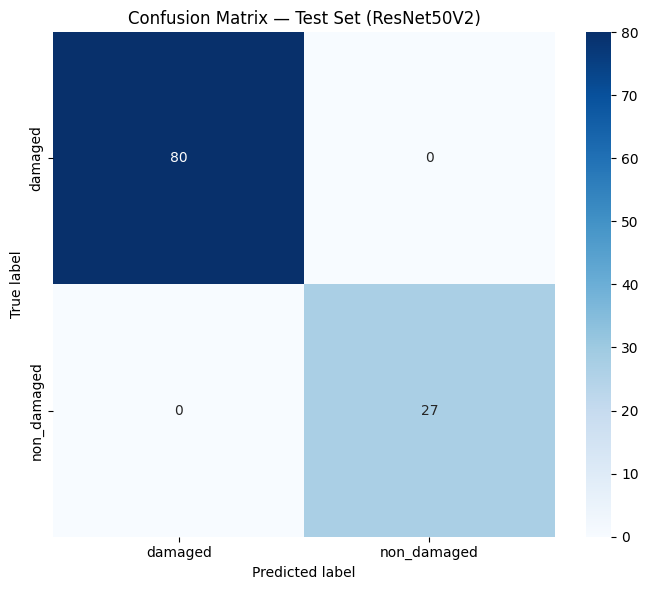

Saved → confusion_matrix.png


In [42]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Confusion Matrix — Test Set (ResNet50V2)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()
print('Saved → confusion_matrix.png')

## Step 11 — Export to TFLite INT8 (for Raspberry Pi)

> ResNet50V2 INT8 model will be ~22 MB. Inference on Pi 4 is ~300–500ms/image.

In [43]:
TFLITE_PATH = os.path.join(OUTPUT_DIR, 'bottle_classifier_resnet50v2_int8.tflite')

def representative_dataset_gen():
    raw = image_dataset_from_directory(
        os.path.join(SPLIT_DIR, 'train'),
        image_size=IMG_SIZE, batch_size=1,
        shuffle=True, seed=SEED, label_mode=None
    )
    for i, batch in enumerate(raw):
        if i >= 300:   # ✅ increased (better calibration)
            break

        # ✅ FIX: apply SAME preprocessing used in training
        batch = tf.keras.applications.resnet_v2.preprocess_input(batch)

        yield [batch]

converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset_gen

converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

# ✅ FIX: use float input/output to avoid mismatch issues
converter.inference_input_type  = tf.float32
converter.inference_output_type = tf.float32

tflite_model = converter.convert()

with open(TFLITE_PATH, 'wb') as f:
    f.write(tflite_model)

size_kb = os.path.getsize(TFLITE_PATH) / 1024
print(f'TFLite model saved: {TFLITE_PATH} ({size_kb:.1f} KB)')





Saved artifact at '/tmp/tmpuqiw9dlq'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_602')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  139889916009488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139889916012368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139889916008912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139889916012752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139889916011984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139889916009680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139889916013520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139889916013136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139889916011408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139889916012560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1398899160

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Found 489 files.
TFLite model saved: /content/working/bottle_classifier_resnet50v2_int8.tflite (24229.9 KB)


In [44]:

# FP32 TFLite

FLOAT_TFLITE_PATH = os.path.join(OUTPUT_DIR, 'bottle_classifier_resnet50v2_fp32.tflite')

converter = tf.lite.TFLiteConverter.from_keras_model(model)

tflite_model_fp32 = converter.convert()

with open(FLOAT_TFLITE_PATH, 'wb') as f:
    f.write(tflite_model_fp32)

size_kb = os.path.getsize(FLOAT_TFLITE_PATH) / 1024
print(f'FP32 TFLite model saved: {FLOAT_TFLITE_PATH} ({size_kb:.1f} KB)')

Saved artifact at '/tmp/tmpz7qkly3b'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_602')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  139889916009488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139889916012368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139889916008912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139889916012752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139889916011984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139889916009680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139889916013520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139889916013136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139889916011408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139889916012560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1398899160

## Step 12 — Verify TFLite model on test images

In [ ]:
from PIL import Image as PILImage

def predict_tflite(image_path: str) -> dict:
    interpreter = tf.lite.Interpreter(model_path=TFLITE_PATH)
    interpreter.allocate_tensors()

    in_det  = interpreter.get_input_details()[0]
    out_det = interpreter.get_output_details()[0]

    img = PILImage.open(image_path).convert('RGB').resize(IMG_SIZE)

    #   preprocessing
    img_array = np.array(img, dtype=np.float32)
    img_array = tf.keras.applications.resnet_v2.preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    interpreter.set_tensor(in_det['index'], img_array)
    interpreter.invoke()

    output = interpreter.get_tensor(out_det['index'])[0]

    return {CLASS_NAMES[i]: float(output[i]) for i in range(len(CLASS_NAMES))}

print('TFLite verification:')
for cls in CLASS_NAMES:
    test_cls_dir = os.path.join(SPLIT_DIR, 'test', cls)
    files = [f for f in os.listdir(test_cls_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    if files:
        result    = predict_tflite(os.path.join(test_cls_dir, files[0]))
        predicted = max(result, key=result.get)
        conf      = result[predicted]
        status    = '✓' if predicted == cls else '✗'
        print(f'  {status} True: {cls:12s} | Predicted: {predicted:12s} | Confidence: {conf:.2%}')


TFLite verification:


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


  ✓ True: damaged      | Predicted: damaged      | Confidence: 69.92%
  ✓ True: non_damaged  | Predicted: non_damaged  | Confidence: 77.73%


In [66]:
!pip install -q tensorflow-model-optimization tf_keras

In [75]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'
import tensorflow as tf
import tf_keras
import tensorflow_model_optimization as tfmot
from sklearn.metrics import classification_report
import numpy as np

# 1. Setup Base Model using tf_keras for full consistency
base_model = tf_keras.applications.ResNet50V2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

# 2. Build the head using tf_keras
head_model = tf_keras.Sequential([
    tf_keras.layers.InputLayer(input_shape=base_model.output_shape[1:]),
    tf_keras.layers.GlobalAveragePooling2D(),
    tf_keras.layers.Dense(256, activation='relu'),
    tf_keras.layers.Dropout(0.57),
    tf_keras.layers.Dense(128, activation='relu'),
    tf_keras.layers.Dropout(0.30),
    tf_keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

# 3. Apply Quantization to the head
q_aware_head = tfmot.quantization.keras.quantize_model(head_model)

# 4. Assemble Full Model entirely in tf_keras
inputs = tf_keras.Input(shape=IMG_SIZE + (3,))
x = base_model(inputs, training=False)
outputs = q_aware_head(x)
q_aware_model = tf_keras.Model(inputs, outputs)

q_aware_model.compile(
    optimizer=tf_keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Define Early Stopping for QAT
qat_callbacks = [
    tf_keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
]

print('Starting Quantization Aware Training (Keras 2 legacy mode)...')
# Explicitly save the history object
history_qat = q_aware_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=CLASS_WEIGHTS,
    callbacks=qat_callbacks
)

# 5. Final Evaluation
print('\n── QAT Performance Report ──')
y_true, y_pred = [], []
for images, labels in test_ds:
    preds = q_aware_model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(np.array(y_true), np.array(y_pred), target_names=CLASS_NAMES))

Starting Quantization Aware Training (Keras 2 legacy mode)...
Epoch 1/30
31/31 [==============================] - 16s 346ms/step - loss: 1.0722 - accuracy: 0.4990 - val_loss: 0.5663 - val_accuracy: 0.7767
Epoch 2/30
31/31 [==============================] - 10s 320ms/step - loss: 0.9186 - accuracy: 0.5685 - val_loss: 0.5024 - val_accuracy: 0.8447
Epoch 3/30
31/31 [==============================] - 11s 326ms/step - loss: 0.8949 - accuracy: 0.5665 - val_loss: 0.4556 - val_accuracy: 0.8835
Epoch 4/30
31/31 [==============================] - 11s 348ms/step - loss: 0.7625 - accuracy: 0.6237 - val_loss: 0.4041 - val_accuracy: 0.9126
Epoch 5/30
31/31 [==============================] - 11s 346ms/step - loss: 0.6475 - accuracy: 0.6973 - val_loss: 0.3678 - val_accuracy: 0.9417
Epoch 6/30
31/31 [==============================] - 9s 273ms/step - loss: 0.6763 - accuracy: 0.6708 - val_loss: 0.3348 - val_accuracy: 0.9515
Epoch 7/30
31/31 [==============================] - 10s 312ms/step - loss: 0.7266

In [76]:
# Save the QAT model as a TFLite model
# This is the final step to get the optimized file for Raspberry Pi

converter = tf.lite.TFLiteConverter.from_keras_model(q_aware_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

qat_tflite_model = converter.convert()

QAT_TFLITE_PATH = os.path.join(OUTPUT_DIR, 'bottle_classifier_resnet50v2_qat.tflite')
with open(QAT_TFLITE_PATH, 'wb') as f:
    f.write(qat_tflite_model)

print(f'QAT TFLite model saved: {QAT_TFLITE_PATH}')

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


QAT TFLite model saved: /content/working/bottle_classifier_resnet50v2_qat.tflite


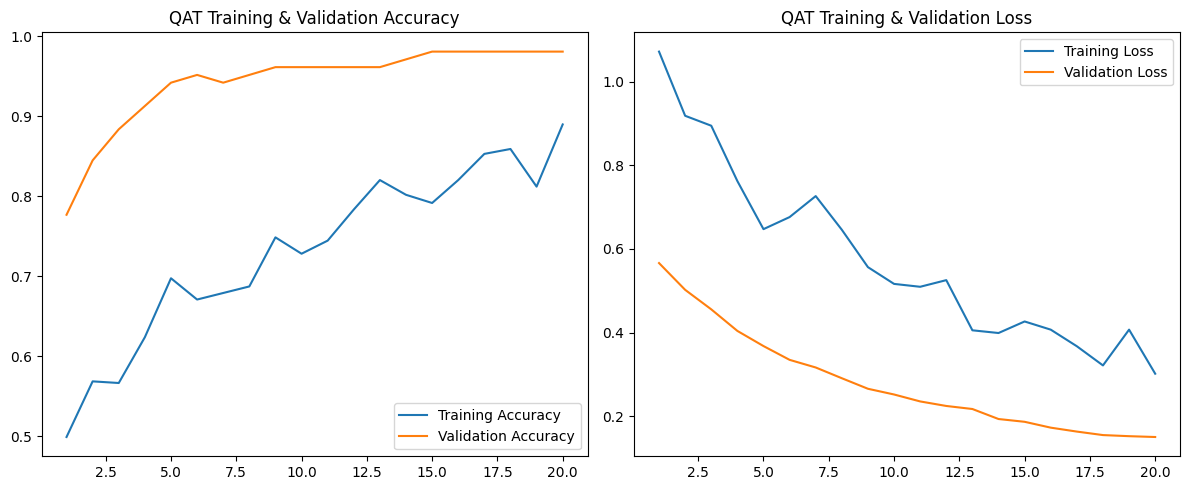

In [77]:
# Plotting QAT Training History
def plot_qat_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('QAT Training & Validation Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('QAT Training & Validation Loss')
    plt.legend()

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'qat_training_curves.png'))
    plt.show()

try:
    plot_qat_history(history_qat)
except NameError:
    print('History not found. Please ensure the training cell has finished.')

## Step 13 — Save labels file

In [ ]:
LABELS_PATH = os.path.join(OUTPUT_DIR, 'labels.txt')
with open(LABELS_PATH, 'w') as f:
    f.write('\n'.join(CLASS_NAMES))
print(f'Labels saved → {LABELS_PATH}')
print('Contents:', CLASS_NAMES)


Labels saved → /kaggle/working/labels.txt
Contents: ['damaged', 'non_damaged']


In [27]:
import os
print(os.listdir('/kaggle/working'))

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working'

In [ ]:
import os

print(os.listdir('/kaggle/input/datasets/nainaarabha/crop-data/damaged')[:10])

['bottle_1t 4_crop0_0.96.jpg', 'bottle_413t_crop0_0.95.jpg', 'bottle_58t_crop0_0.97.jpg', 'bottle_305t_crop0_0.97.jpg', 'bottle_0016_crop0_0.96.jpg', 'bottle_433t_crop0_0.96.jpg', 'bottle_226t_crop0_0.95.jpg', 'bottle_93t 2_crop0_0.97.jpg', 'bottle_258t_crop0_0.97.jpg', 'bottle_470t_crop0_0.95.jpg']


In [ ]:
import tensorflow as tf
import cv2
import numpy as np

CLASS_NAMES = ['damaged', 'non_damaged']

# Load model
model = tf.keras.models.load_model('/content/working/bottle_classifier_resnet50v2_fp32.keras')

# Load image from Drive path
img = cv2.imread('/content/drive/MyDrive/edge/nondamaged1/Gemini_Generated_Image_n_bottle_0_Damaged.jpg')

if img is not None:
    img = cv2.resize(img, (224, 224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # SAME preprocessing as training
    img = tf.keras.applications.resnet_v2.preprocess_input(img)
    img = np.expand_dims(img, axis=0)

    # Predict
    pred = model.predict(img)
    pred_class = CLASS_NAMES[np.argmax(pred)]
    confidence = np.max(pred)

    print("Prediction:", pred_class)
    print("Confidence:", confidence)
else:
    print("Error: Image not found at path.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Prediction: non_damaged
Confidence: 0.72518027


In [ ]:
import tensorflow as tf
import cv2
import numpy as np

CLASS_NAMES = ['damaged', 'non_damaged']
MODEL_PATH = '/content/working/bottle_classifier_resnet50v2_int8.tflite'

# Load TFLite model
interpreter = tf.lite.Interpreter(model_path=MODEL_PATH)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

# Load image from Drive path
img = cv2.imread('/content/drive/MyDrive/edge/nondamaged1/Gemini_Generated_Image_n_bottle_0_Damaged.jpg')

if img is None:
    print("Image not found!")
else:
    img = cv2.resize(img, (224, 224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # SAME preprocessing
    img = tf.keras.applications.resnet_v2.preprocess_input(img)
    img = np.expand_dims(img, axis=0)

    # Run inference
    interpreter.set_tensor(input_details['index'], img)
    interpreter.invoke()

    pred = interpreter.get_tensor(output_details['index'])[0]
    pred_class = CLASS_NAMES[np.argmax(pred)]
    confidence = np.max(pred)

    print("Prediction:", pred_class)
    print("Confidence:", confidence)

Prediction: non_damaged
Confidence: 0.59765625


## Step 14 — Summary of output files

In [ ]:
print('=' * 55)
print('OUTPUT FILES  (available in the Output tab on the right)')
print('=' * 55)

expected = [
    'bottle_classifier_resnet50v2_int8.tflite',
    'labels.txt',
    'training_curves.png',
    'confusion_matrix.png',
    'augmented_samples.png',
    'best_phase1.keras',
    'best_phase2.keras',
]

for fname in expected:
    fpath = os.path.join(OUTPUT_DIR, fname)
    if os.path.exists(fpath):
        size_kb = os.path.getsize(fpath) / 1024
        print(f'  ✓ {fname:<45} {size_kb:>8.1f} KB')
    else:
        print(f'  ✗ {fname:<45} NOT FOUND')

print('\nDone! Download the .tflite and labels.txt for your Raspberry Pi.')


OUTPUT FILES  (available in the Output tab on the right)
  ✓ bottle_classifier_resnet50v2_int8.tflite       24230.0 KB
  ✓ labels.txt                                         0.0 KB
  ✓ training_curves.png                              150.8 KB
  ✓ confusion_matrix.png                              43.2 KB
  ✓ augmented_samples.png                           1366.6 KB
  ✓ best_phase1.keras                              99334.0 KB
  ✓ best_phase2.keras                             212194.3 KB

Done! Download the .tflite and labels.txt for your Raspberry Pi.


In [ ]:
import tensorflow as tf
import cv2
import numpy as np
import os

CLASS_NAMES = ['damaged', 'non_damaged']
model = tf.keras.models.load_model('/content/working/bottle_classifier_resnet50v2_fp32.keras')

DATASET_PATH = '/content/drive/MyDrive/edge/non-damaged'

if os.path.exists(DATASET_PATH):
    # Loop through all images
    for file in os.listdir(DATASET_PATH):
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(DATASET_PATH, file)
            img = cv2.imread(img_path)

            if img is None:
                print(f"Skipping (not readable): {file}")
                continue

            img = cv2.resize(img, (224, 224))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = tf.keras.applications.resnet_v2.preprocess_input(img)
            img = np.expand_dims(img, axis=0)

            pred = model.predict(img, verbose=0)
            pred_class = CLASS_NAMES[np.argmax(pred)]
            confidence = np.max(pred)
            print(f"{file} → {pred_class} ({confidence:.4f})")
else:
    print(f"Path not found: {DATASET_PATH}")